# Total Test for boundary age (18-24)

In [1]:
# ── Imports & Setup ──────────────────────────────────────────────────────────
import csv
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path('D:/JiShou/D-Y2S3/BMCS2074 - Artificial Intelligence/Assignment/AI_Assignment')
CNN_RESULTS  = PROJECT_ROOT / 'Model/CNN/runs/cnn_age_detector/test_results'
HOG_RESULTS  = PROJECT_ROOT / 'Model/HOG_SVM/runs/hog_svm_adult_binary/test_results'
VIT_RESULTS  = PROJECT_ROOT / 'Model/ViT/runs/vit_adult_binary/test_results'
OUT_DIR      = CNN_RESULTS  # output goes alongside CNN results

# ── Load rows from CNN predictions ───────────────────────────────────────────
pred_csv_path = CNN_RESULTS / 'test_predictions.csv'
rows = pd.read_csv(pred_csv_path).to_dict('records')
print(f'Loaded {len(rows)} rows from CNN predictions')
print(f'Columns: {list(rows[0].keys()) if rows else []}')


Loaded 3945 rows from CNN predictions
Columns: ['name', 'image_path', 'age', 'dis', 'prob_adult', 'pred_label', 'pred_class', 'true_label', 'true_class']


Boundary Metrics JSON: D:\JiShou\D-Y2S3\BMCS2074 - Artificial Intelligence\Assignment\AI_Assignment\Model\CNN\runs\cnn_age_detector\test_results\test_boundary_metrics.json
Boundary samples (age 18-24): 690

Boundary metrics:
  total: 690
  accuracy: 0.484058
  precision: 0.856383
  recall: 0.328571
  f1: 0.474926
  tp: 161
  tn: 173
  fp: 27
  fn: 329


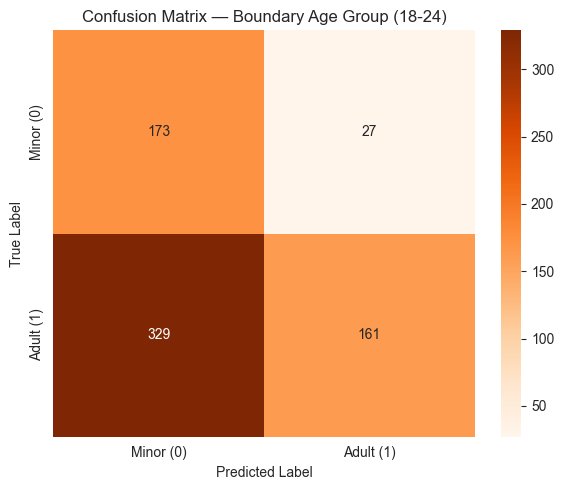

In [2]:
# ── Boundary Age Group Analysis (18-24) ─────────────────────────────────────
BOUNDARY_AGE_MIN = 18
BOUNDARY_AGE_MAX = 24

def compute_boundary_metrics_from_rows(rows, min_age=18, max_age=24):
    """Compute metrics for the boundary age range [min_age, max_age]."""
    boundary = [r for r in rows if r.get('age') is not None and min_age <= r['age'] <= max_age]
    if not boundary:
        return None, 0
    y_true = [int(r['true_label']) for r in boundary]
    y_pred = [int(r['pred_label']) for r in boundary]
    total = len(y_true)
    tp = sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 1)
    tn = sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 0)
    fp = sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 1)
    fn = sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 0)
    precision = tp / max(tp + fp, 1)
    recall    = tp / max(tp + fn, 1)
    f1        = 2 * precision * recall / max(precision + recall, 1e-12)
    accuracy  = (tp + tn) / max(total, 1)
    return {
        'total': total, 'accuracy': accuracy, 'precision': precision,
        'recall': recall, 'f1': f1, 'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn,
    }, len(boundary)

boundary_metrics, boundary_n = compute_boundary_metrics_from_rows(rows, BOUNDARY_AGE_MIN, BOUNDARY_AGE_MAX)

boundary_metrics_json_path = OUT_DIR / 'test_boundary_metrics.json'
if boundary_metrics is not None:
    with boundary_metrics_json_path.open('w', encoding='utf-8') as f:
        json.dump(boundary_metrics, f, indent=2)
    print(f'Boundary Metrics JSON: {boundary_metrics_json_path}')
    print(f'Boundary samples (age {BOUNDARY_AGE_MIN}-{BOUNDARY_AGE_MAX}): {boundary_n}')
    print('\nBoundary metrics:')
    for k, v in boundary_metrics.items():
        print(f'  {k}: {v:.6f}' if isinstance(v, float) else f'  {k}: {v}')

    # Boundary confusion matrix
    y_true_b = [int(r['true_label']) for r in rows if BOUNDARY_AGE_MIN <= r['age'] <= BOUNDARY_AGE_MAX]
    y_pred_b = [int(r['pred_label']) for r in rows if BOUNDARY_AGE_MIN <= r['age'] <= BOUNDARY_AGE_MAX]
    cm_b = confusion_matrix(y_true_b, y_pred_b)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm_b,
        annot=True, fmt='d', cmap='Oranges',
        xticklabels=['Minor (0)', 'Adult (1)'],
        yticklabels=['Minor (0)', 'Adult (1)'],
    )
    plt.title(f'Confusion Matrix — Boundary Age Group ({BOUNDARY_AGE_MIN}-{BOUNDARY_AGE_MAX})')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
else:
    print(f'No boundary samples found in range {BOUNDARY_AGE_MIN}-{BOUNDARY_AGE_MAX}.')


In [3]:
# ── All-model boundary summary ────────────────────────────────────────────────
boundary_summary = {}
for model_name, csv_path in [
    ('HOG + SVM', HOG_RESULTS / 'test_predictions.csv'),
    ('ViT',       VIT_RESULTS / 'test_predictions.csv'),
    ('CNN',       CNN_RESULTS / 'test_predictions.csv'),
]:
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        if 'age' in df.columns and 'true_label' in df.columns and 'pred_label' in df.columns:
            bdf = df[(df['age'] >= BOUNDARY_AGE_MIN) & (df['age'] <= BOUNDARY_AGE_MAX)]
            total = len(bdf)
            if total > 0:
                tp = int(((bdf['pred_label'] == 1) & (bdf['true_label'] == 1)).sum())
                tn = int(((bdf['pred_label'] == 0) & (bdf['true_label'] == 0)).sum())
                fp = int(((bdf['pred_label'] == 1) & (bdf['true_label'] == 0)).sum())
                fn = int(((bdf['pred_label'] == 0) & (bdf['true_label'] == 1)).sum())
                acc  = (tp + tn) / total
                prec = tp / max(tp + fp, 1)
                rec  = tp / max(tp + fn, 1)
                f1   = 2 * prec * rec / max(prec + rec, 1e-12)
                boundary_summary[model_name] = {
                    'boundary_samples': total,
                    'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1,
                    'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn,
                }

print('\n=== Boundary Age Group (18-24) Summary Across All Models ===')
if boundary_summary:
    summary_df = pd.DataFrame(boundary_summary).T
    summary_df = summary_df[['boundary_samples','accuracy','precision','recall','f1','tp','tn','fp','fn']]
    display(summary_df.style.format('{:.4f}', subset=['accuracy','precision','recall','f1']))
else:
    print('No boundary data available.')



=== Boundary Age Group (18-24) Summary Across All Models ===


,boundary_samples,accuracy,precision,recall,f1,tp,tn,fp,fn
HOG + SVM,690.000000,0.4493,0.7696,0.3204,0.4524,157.000000,153.000000,47.000000,333.000000
ViT,690.000000,0.5783,0.8119,0.5286,0.6403,259.000000,140.000000,60.000000,231.000000
CNN,690.000000,0.4841,0.8564,0.3286,0.4749,161.000000,173.000000,27.000000,329.000000
